In [1]:
# Setup: paths and imports
import sys
from pathlib import Path

import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

SCENARIO_PATH = ROOT / 'scenarios' / 'scenario_base.yaml'
YEARS = 3

In [2]:
# Load scenario and resolve settings paths
with open(SCENARIO_PATH) as f:
    scenario = yaml.safe_load(f)

settings = {
    key: ROOT / scenario[key]
    for key in [
        'data_registry', 'community', 'farm_profiles',
        'water_systems', 'water_policy',
        'energy_system', 'energy_policy',
    ]
}

print(f"Scenario: {scenario['scenario_name']}")
print(f"Description: {scenario['description']}")
for key, path in settings.items():
    status = 'OK' if path.exists() else 'MISSING'
    print(f"  {key}: {path.name} [{status}]")

Scenario: baseline
Description: Baseline community — research-grade energy data, toy-grade water and building data
  data_registry: data_registry_base.yaml [OK]
  community: community_demands_base.yaml [OK]
  farm_profiles: farm_profile_base.yaml [OK]
  water_systems: water_systems_base.yaml [OK]
  water_policy: water_policy_base.yaml [OK]
  energy_system: energy_system_base.yaml [OK]
  energy_policy: energy_policy_base.yaml [OK]


In [3]:
# Compute daily water balance from scenario settings
from src.water_balance import compute_daily_water_balance

df = compute_daily_water_balance(
    farm_profiles_path=settings['farm_profiles'],
    water_systems_path=settings['water_systems'],
    water_policy_path=settings['water_policy'],
    community_config_path=settings['community'],
    registry_path=settings['data_registry'],
)

print(f"Computed {len(df)} days")
print(f"Date range: {df['day'].min().date()} to {df['day'].max().date()}")
print(f"Total irrigation demand: {df['irrigation_demand_m3'].sum():,.0f} m\u00b3")
print(f"Total community water:   {df['community_water_demand_m3'].sum():,.0f} m\u00b3")
print(f"Total deficit:           {df['deficit_m3'].sum():,.0f} m\u00b3")
print(f"Total energy:            {df['total_water_energy_kwh'].sum():,.1f} kWh")
print(f"Total cost:              ${df['total_water_cost'].sum():,.2f}")

Computed 5479 days
Date range: 2010-01-01 to 2024-12-31
Total irrigation demand: 1,121,194 m³
Total community water:   154,882 m³
Total deficit:           0 m³
Total energy:            1,981,208.3 kWh
Total cost:              $626,624.88


In [4]:
# Compute harvest yields for all fields, plantings, and years
from src.crop_yield import compute_community_harvest, save_harvest_yields

harvest_df, harvests = compute_community_harvest(
    df,
    farm_profiles_path=settings['farm_profiles'],
    registry_path=settings['data_registry'],
)

print(f"Computed {len(harvests)} harvest events across {df['day'].min().year}-{df['day'].max().year}")
print(f"\nHarvest summary by crop:")
for crop, group in harvests.groupby('crop'):
    avg_yield = group['yield_kg_per_ha'].mean()
    total_kg = group['harvest_kg'].sum()
    print(f"  {crop}: {len(group)} harvests, avg {avg_yield:,.0f} kg/ha, total {total_kg:,.0f} kg")

Computed 118 harvest events across 2010-2024

Harvest summary by crop:
  cucumber: 30 harvests, avg 35,548 kg/ha, total 1,066,442 kg
  kale: 29 harvests, avg 20,882 kg/ha, total 605,576 kg
  onion: 15 harvests, avg 35,953 kg/ha, total 539,293 kg
  potato: 14 harvests, avg 28,524 kg/ha, total 399,331 kg
  tomato: 30 harvests, avg 49,932 kg/ha, total 1,497,965 kg


In [5]:
# Save daily harvest yields CSV
output_path = save_harvest_yields(harvest_df, output_dir=ROOT / 'simulation')

harvest_days = (harvest_df['total_harvest_kg'] > 0).sum()
print(f"Saved {len(harvest_df)} days to {output_path.name}")
print(f"Days with harvests: {harvest_days}")
print(f"Total harvest: {harvest_df['total_harvest_kg'].sum():,.0f} kg")
print(f"\nSample harvest days:")
print(harvest_df[harvest_df['total_harvest_kg'] > 0].head(10).to_string(index=False))

Saved 5479 days to daily_harvest_yields.csv
Days with harvests: 118
Total harvest: 4,108,607 kg

Sample harvest days:
       day  east_field_cucumber_harvest_kg  north_field_kale_harvest_kg  north_field_tomato_harvest_kg  south_field_onion_harvest_kg  south_field_potato_harvest_kg  west_field_kale_harvest_kg  west_field_tomato_harvest_kg  total_harvest_kg
2010-05-21                         36474.5                          0.0                            0.0                           0.0                            0.0                         0.0                           0.0           36474.5
2010-06-14                             0.0                          0.0                            0.0                       37621.9                            0.0                         0.0                           0.0           37621.9
2010-06-30                             0.0                          0.0                        54389.3                           0.0                            0.

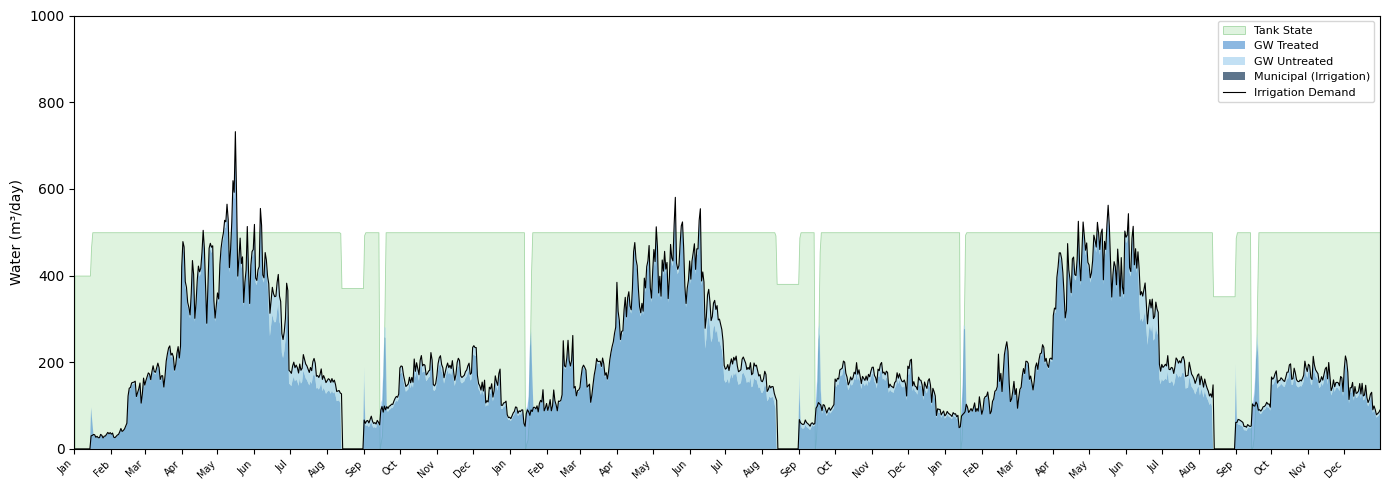

In [6]:
# Water balance: supply (stacked), demand (lines), and tank state
from src.plots import plot_water_balance

fig = plot_water_balance(df, years=YEARS)
plt.show()

/Users/dpbirge/GITHUB/community-agri-pv/src/plots.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


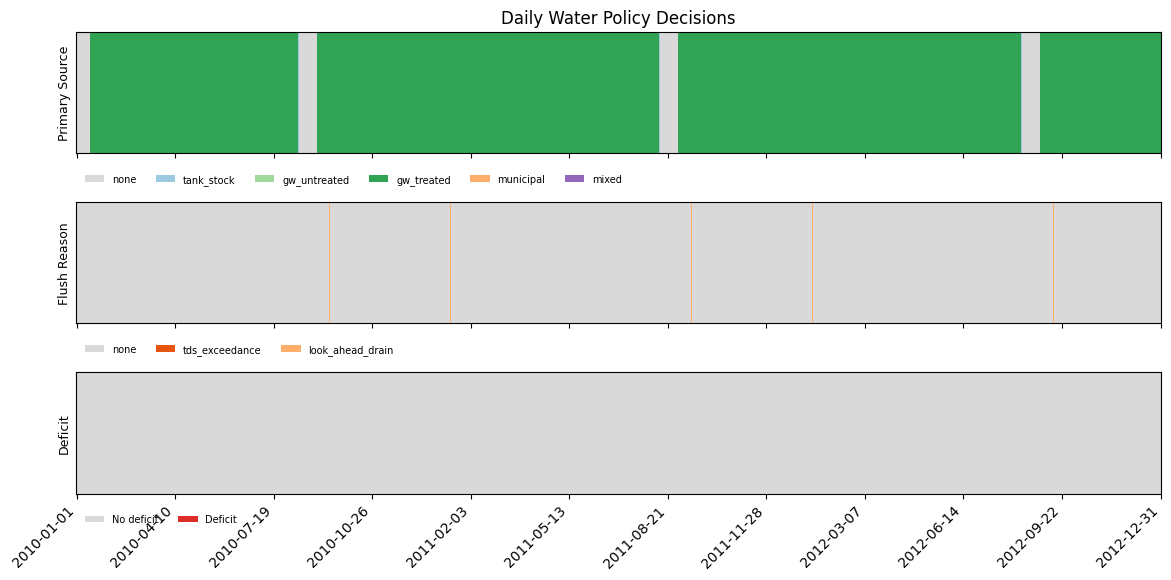

In [7]:
# Policy decisions heatmap (primary source, flush reason, deficit)
from src.plots import plot_water_policy_heatmap

fig = plot_water_policy_heatmap(df, years=YEARS)
plt.show()

In [8]:
# Annual summary statistics
import pandas as pd

annual = df.groupby(df['day'].dt.year).agg(
    irrigation_demand_m3=('irrigation_demand_m3', 'sum'),
    community_water_m3=('community_water_demand_m3', 'sum'),
    total_delivered_m3=('irrigation_delivered_m3', 'sum'),
    deficit_m3=('deficit_m3', 'sum'),
    gw_untreated_m3=('gw_untreated_to_tank_m3', 'sum'),
    gw_treated_m3=('gw_treated_to_tank_m3', 'sum'),
    municipal_irrig_m3=('municipal_to_tank_m3', 'sum'),
    total_water_energy_kwh=('total_water_energy_kwh', 'sum'),
    total_cost_usd=('total_water_cost', 'sum'),
).round(1)

annual.index.name = 'year'
annual

,irrigation_demand_m3,community_water_m3,total_delivered_m3,deficit_m3,gw_untreated_m3,gw_treated_m3,municipal_irrig_m3,total_water_energy_kwh,total_cost_usd
year,,,,,,,,,
2010,72347.6,10330.4,72847.6,0.0,5029.0,67918.6,0.0,126402.4,40377.0
2011,72450.1,10292.8,73450.1,0.0,4986.4,68463.7,0.0,129162.9,40670.2
2012,74277.0,10402.1,75277.0,0.0,5095.6,70181.4,0.0,131260.0,41594.5
2013,75279.3,10476.8,76279.3,0.0,5022.1,71257.2,0.0,133156.5,42191.3
2014,75036.7,10380.1,76036.7,0.0,5124.2,70912.5,0.0,132714.0,41945.5
2015,73898.8,10323.7,74898.8,0.0,5021.0,69877.8,0.0,131327.3,41421.4
2016,75724.4,10485.4,76724.4,0.0,5169.4,71554.9,0.0,133621.4,42337.3
2017,75534.8,10443.2,76534.8,0.0,5177.6,71357.2,0.0,133391.2,42224.5
2018,74558.3,10354.6,75558.3,0.0,5032.7,70525.5,0.0,132104.6,41746.4


In [9]:
# Compute daily energy balance (supply, demand, battery, grid, generator dispatch)
from src.energy_balance import compute_daily_energy_balance

energy_df = compute_daily_energy_balance(
    energy_config_path=settings['energy_system'],
    energy_policy_path=settings['energy_policy'],
    community_config_path=settings['community'],
    farm_profiles_path=settings['farm_profiles'],
    registry_path=settings['data_registry'],
    water_balance_df=df,
)

print(f"Computed {len(energy_df)} days")
print(f"Date range: {energy_df['day'].min().date()} to {energy_df['day'].max().date()}")
print(f"Total demand:        {energy_df['total_demand_kwh'].sum():,.0f} kWh")
print(f"  Community bldg:    {energy_df['community_energy_demand_kwh'].sum():,.0f} kWh")
print(f"  Water systems:     {energy_df['water_energy_demand_kwh'].sum():,.0f} kWh")
print(f"Total renewable:     {energy_df['total_renewable_kwh'].sum():,.0f} kWh")
print(f"Grid import:         {energy_df['grid_import_kwh'].sum():,.0f} kWh")
print(f"Grid export:         {energy_df['grid_export_kwh'].sum():,.0f} kWh")
print(f"Generator:           {energy_df['generator_kwh'].sum():,.0f} kWh")
print(f"Curtailed:           {energy_df['curtailed_kwh'].sum():,.0f} kWh")
print(f"Deficit:             {energy_df['deficit_kwh'].sum():,.0f} kWh")
print(f"Total energy cost:   ${energy_df['total_energy_cost'].sum():,.2f}")

Computed 5479 days
Date range: 2010-01-01 to 2024-12-31
Total demand:        5,899,767 kWh
  Community bldg:    3,918,558 kWh
  Water systems:     1,981,208 kWh
Total renewable:     91,645,282 kWh
Grid import:         0 kWh
Grid export:         0 kWh
Generator:           0 kWh
Curtailed:           85,745,421 kWh
Deficit:             0 kWh
Total energy cost:   $0.00


In [10]:
# Save daily energy balance CSV
from src.energy_balance import save_energy_balance

energy_output = save_energy_balance(energy_df, output_dir=ROOT / 'simulation')
print(f"Saved {len(energy_df)} days to {energy_output.name}")

Saved 5479 days to daily_energy_balance.csv


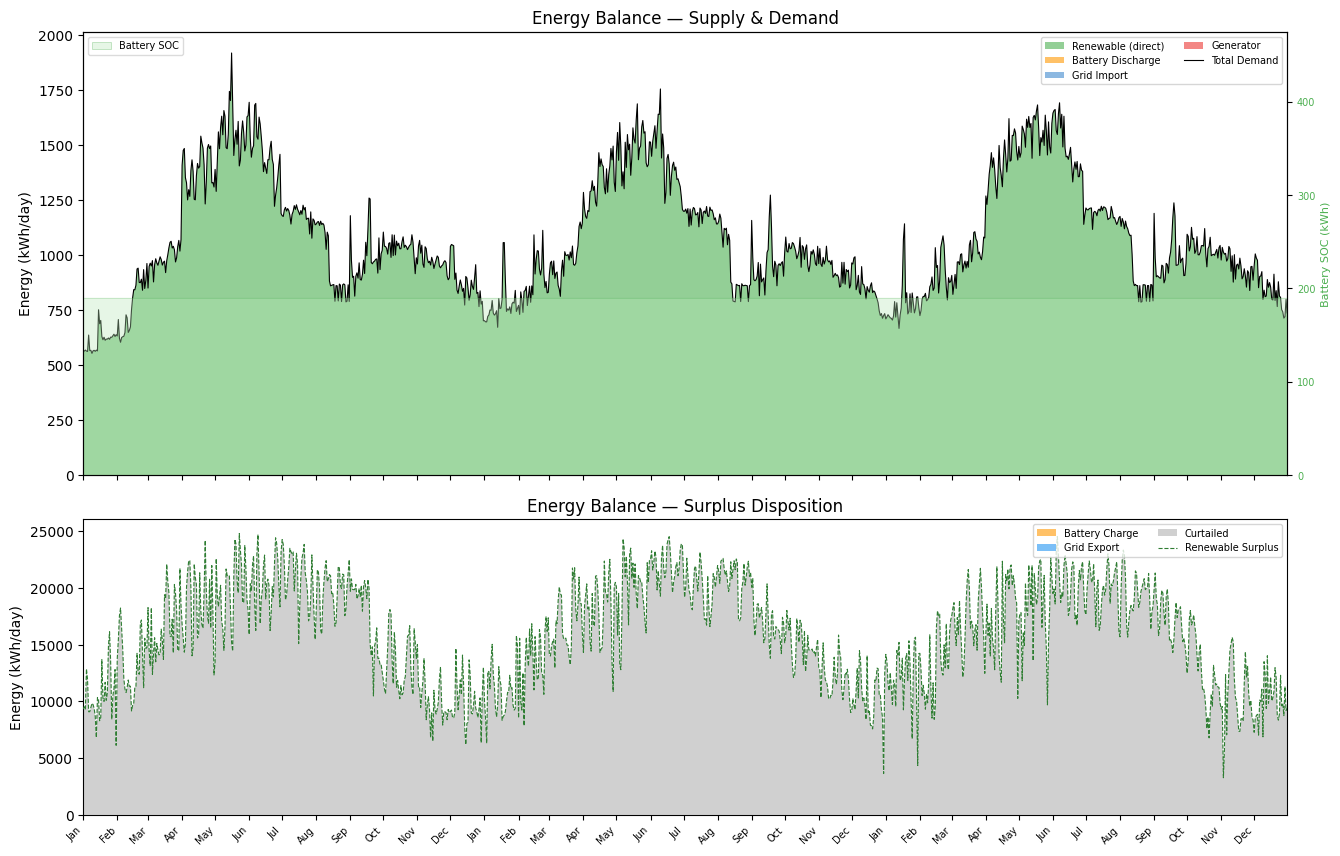

In [11]:
# Energy balance: supply stack, demand line, battery SOC, surplus disposition
from src.plots import plot_energy_balance

fig = plot_energy_balance(energy_df, years=YEARS)
plt.show()

In [12]:
# Annual energy balance summary
energy_annual = energy_df.groupby(energy_df['day'].dt.year).agg(
    community_demand_kwh=('community_energy_demand_kwh', 'sum'),
    water_demand_kwh=('water_energy_demand_kwh', 'sum'),
    total_demand_kwh=('total_demand_kwh', 'sum'),
    total_renewable_kwh=('total_renewable_kwh', 'sum'),
    renewable_consumed_kwh=('renewable_consumed_kwh', 'sum'),
    battery_charge_kwh=('battery_charge_kwh', 'sum'),
    battery_discharge_kwh=('battery_discharge_kwh', 'sum'),
    grid_import_kwh=('grid_import_kwh', 'sum'),
    grid_export_kwh=('grid_export_kwh', 'sum'),
    generator_kwh=('generator_kwh', 'sum'),
    curtailed_kwh=('curtailed_kwh', 'sum'),
    deficit_kwh=('deficit_kwh', 'sum'),
    total_energy_cost=('total_energy_cost', 'sum'),
).round(1)

energy_annual.index.name = 'year'
energy_annual

,community_demand_kwh,water_demand_kwh,total_demand_kwh,total_renewable_kwh,renewable_consumed_kwh,battery_charge_kwh,battery_discharge_kwh,grid_import_kwh,grid_export_kwh,generator_kwh,curtailed_kwh,deficit_kwh,total_energy_cost
year,,,,,,,,,,,,,
2010,262474.2,126402.4,388876.6,6187329.0,388876.6,94.7,0.0,0.0,0.0,0.0,5798357.6,0.0,0.0
2011,259383.1,129162.9,388546.0,6383028.4,388546.0,0.0,0.0,0.0,0.0,0.0,5994482.4,0.0,0.0
2012,266567.2,131260.0,397827.2,6155681.9,397827.2,0.0,0.0,0.0,0.0,0.0,5757854.7,0.0,0.0
2013,273371.3,133156.5,406527.8,6249277.4,406527.8,0.0,0.0,0.0,0.0,0.0,5842749.6,0.0,0.0
2014,265827.2,132714.0,398541.2,6196144.1,398541.2,0.0,0.0,0.0,0.0,0.0,5797602.8,0.0,0.0
2015,261100.2,131327.3,392427.5,6151639.8,392427.5,0.0,0.0,0.0,0.0,0.0,5759212.3,0.0,0.0
2016,272360.6,133621.4,405982.0,6110860.8,405982.0,0.0,0.0,0.0,0.0,0.0,5704878.8,0.0,0.0
2017,271892.8,133391.2,405284.0,6196871.3,405284.0,0.0,0.0,0.0,0.0,0.0,5791587.3,0.0,0.0
2018,263337.3,132104.6,395441.9,5953931.5,395441.9,0.0,0.0,0.0,0.0,0.0,5558489.6,0.0,0.0
